In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import joblib

# Load both datasets
df1 = pd.read_csv("dataset_phishing.csv", low_memory=False)
df2 = pd.read_csv("dataset_link_phishing.csv", low_memory=False)

# Drop index col if exists
for df in [df1, df2]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

print("Dataset 1:", df1.shape)
print("Dataset 2:", df2.shape)


Dataset 1: (11430, 89)
Dataset 2: (19431, 86)


In [ ]:
# Normalize labels
df1["status"] = df1["status"].map({"phishing": 1, "legitimate": 0})
df2["status"] = df2["status"].map({"phishing": 1, "legitimate": 0})

# Rename columns for consistency
df1 = df1.rename(columns={
    "length_url": "url_length",
    "length_hostname": "hostname_length"
})

# Feature sets
light_features = [
    "url_length", "hostname_length", "ip", "https_token",
    "ratio_digits_url", "ratio_digits_host",
    "prefix_suffix", "shortening_service", "random_domain",
    "dns_record", "domain_age"
]

full_features = light_features + [
    "domain_registration_length", "web_traffic",
    "google_index", "page_rank",
    "nb_hyperlinks", "ratio_intHyperlinks", "ratio_extHyperlinks",
    "login_form", "iframe", "popup_window", "safe_anchor",
    "submit_email", "onmouseover"
]


# Keep aligned columns
df1 = df1[full_features + ["status"]]
df2 = df2[full_features + ["status"]]

# Merge dataset
df = pd.concat([df1, df2], ignore_index=True)
print("Merged dataset shape:", df.shape)
print(df["status"].value_counts())


Merged dataset shape: (30861, 25)
status
0    15431
1    15430
Name: count, dtype: int64


In [ ]:
X = df[full_features]
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)


Train size: (24688, 24) Test size: (6173, 24)


In [ ]:
rf_light = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_light.fit(X_train[light_features], y_train)

# Save model
joblib.dump(rf_light, "rf_model_light.pkl")

# Evaluation
y_pred_light = rf_light.predict(X_test[light_features])
print("Light Model Accuracy:", accuracy_score(y_test, y_pred_light))
print("\nClassification Report:\n", classification_report(y_test, y_pred_light))

cv_scores = cross_val_score(rf_light, X[light_features], y, cv=5, scoring="accuracy")
print("CV Accuracy (Light):", cv_scores.mean())


Light Model Accuracy: 0.8720233273934878

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      3087
           1       0.90      0.84      0.87      3086

    accuracy                           0.87      6173
   macro avg       0.87      0.87      0.87      6173
weighted avg       0.87      0.87      0.87      6173

CV Accuracy (Light): 0.8656880689734601


In [ ]:
rf_full = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_full.fit(X_train[full_features], y_train)

# Save model
joblib.dump(rf_full, "rf_model_full.pkl")

# Evaluation
y_pred_full = rf_full.predict(X_test[full_features])
print("Full Model Accuracy:", accuracy_score(y_test, y_pred_full))
print("\nClassification Report:\n", classification_report(y_test, y_pred_full))

cv_scores = cross_val_score(rf_full, X[full_features], y, cv=5, scoring="accuracy")
print("CV Accuracy (Full):", cv_scores.mean())


Full Model Accuracy: 0.9693827960473028

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97      3087
           1       0.98      0.96      0.97      3086

    accuracy                           0.97      6173
   macro avg       0.97      0.97      0.97      6173
weighted avg       0.97      0.97      0.97      6173

CV Accuracy (Full): 0.9691520019183324


                       Feature  Importance
13                google_index    0.279136
14                   page_rank    0.144239
15               nb_hyperlinks    0.123310
12                 web_traffic    0.103203
17         ratio_extHyperlinks    0.063726
10                  domain_age    0.046221
0                   url_length    0.042389
21                 safe_anchor    0.040579
16         ratio_intHyperlinks    0.037399
4             ratio_digits_url    0.035284
1              hostname_length    0.024582
5            ratio_digits_host    0.021896
11  domain_registration_length    0.019197
6                prefix_suffix    0.005049
7           shortening_service    0.003649
3                  https_token    0.003294
2                           ip    0.001937
9                   dns_record    0.001768
8                random_domain    0.001219
18                  login_form    0.001207


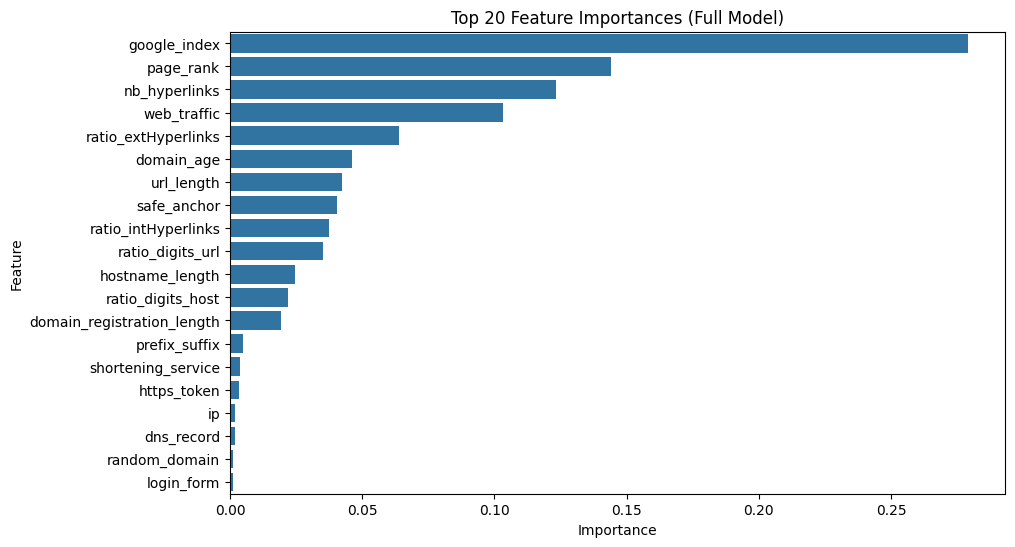

In [ ]:
importances = pd.DataFrame({
    "Feature": full_features,
    "Importance": rf_full.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances.head(20))

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importances.head(20))
plt.title("Top 20 Feature Importances (Full Model)")
plt.show()


/tmp/ipython-input-1844681335.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="False Positives", data=fp_data, palette="viridis")


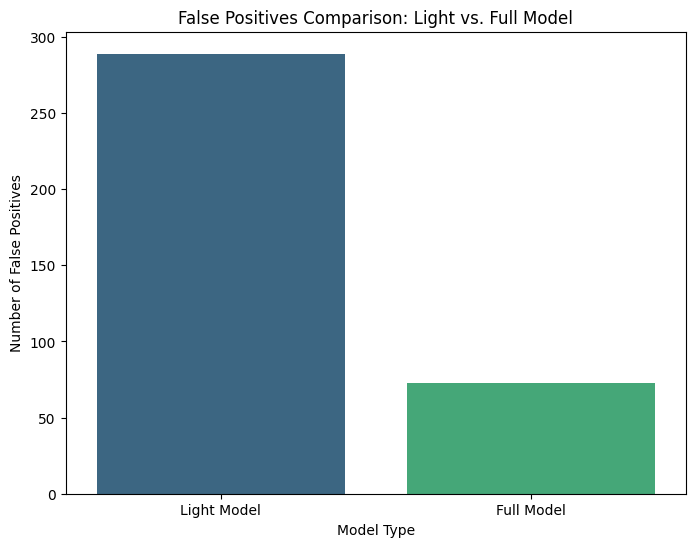

False Positives (Light Model): 289
False Positives (Full Model): 73


In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix for the light model
cm_light = confusion_matrix(y_test, y_pred_light)
# FP is the element at (row 0, column 1) for a binary classification (0=legitimate, 1=phishing)
# True Negative (TN) | False Positive (FP)
# ----------------------------------------
# False Negative (FN) | True Positive (TP)
fp_light = cm_light[0, 1]

# Calculate confusion matrix for the full model
cm_full = confusion_matrix(y_test, y_pred_full)
fp_full = cm_full[0, 1]

# Create a DataFrame for plotting
fp_data = pd.DataFrame({
    "Model": ["Light Model", "Full Model"],
    "False Positives": [fp_light, fp_full]
})

plt.figure(figsize=(8, 6))
sns.barplot(x="Model", y="False Positives", data=fp_data, hue="Model", palette="viridis", legend=False)
plt.title("False Positives Comparison: Light vs. Full Model")
plt.ylabel("Number of False Positives")
plt.xlabel("Model Type")
plt.show()

print(f"False Positives (Light Model): {fp_light}")
print(f"False Positives (Full Model): {fp_full}")

In [ ]:
!pip install python-whois dnspython requests beautifulsoup4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 13.9 MB/s eta 0:00:00


In [ ]:
import requests
from urllib.parse import urlparse
import datetime
import whois
import dns.resolver
from bs4 import BeautifulSoup
import math
import joblib
import pandas as pd

# ================================
# --- Helper functions ---
# ================================
def shannon_entropy(s):
    if not s:
        return 0
    probabilities = [float(s.count(c)) / len(s) for c in set(s)]
    return -sum(p * math.log2(p) for p in probabilities)

def is_random_domain(domain, threshold=4.0):
    try:
        name = domain.split(".")[0]
        entropy = shannon_entropy(name.lower())
        return 1 if entropy > threshold else 0
    except:
        return 0

def get_page_rank(domain):
    try:
        api_key = "k08ccswsocoow0ggw8g4sssccoocgs80k0s8sos4"
        url = f"https://openpagerank.com/api/v1.0/getPageRank?domains[]={domain}"
        headers = {"API-OPR": api_key}
        r = requests.get(url, headers=headers, timeout=5).json()
        if "response" in r and len(r["response"]) > 0:
            rank = r["response"][0].get("rank", 0) or 0
            return int(rank)
        else:
            return 0
    except:
        return 0

# ================================
# --- Feature extraction ---
# ================================
def extract_features(url):
    if not url.startswith(("http://", "https://")):
        url = "http://" + url
    parsed = urlparse(url)
    domain = parsed.netloc.lower()
    features = {}

    # Lexical
    features.update({
        "url_length": len(url),
        "hostname_length": len(parsed.netloc),
        "ip": 1 if parsed.netloc.replace(".", "").isdigit() else 0,
        "https_token": 1 if parsed.scheme == "https" else 0,
        "ratio_digits_url": sum(c.isdigit() for c in url) / len(url) if len(url) > 0 else 0,
        "ratio_digits_host": sum(c.isdigit() for c in parsed.netloc) / len(parsed.netloc) if len(parsed.netloc) > 0 else 0,
        "prefix_suffix": 1 if "-" in parsed.netloc else 0,
        "shortening_service": 1 if any(s in url for s in ["bit.ly", "tinyurl"]) else 0,
        "random_domain": is_random_domain(parsed.netloc)
    })

    # WHOIS & DNS
    try:
        w = whois.whois(domain)
        creation_date = w.creation_date[0] if isinstance(w.creation_date, list) else w.creation_date
        expiration_date = w.expiration_date[0] if isinstance(w.expiration_date, list) else w.expiration_date
        if creation_date:
            features["domain_age"] = (datetime.datetime.now() - creation_date).days // 30
        else:
            features["domain_age"] = 0
        if creation_date and expiration_date:
            features["domain_registration_length"] = (expiration_date - creation_date).days // 30
        else:
            features["domain_registration_length"] = 0
    except:
        features["domain_age"] = 0
        features["domain_registration_length"] = 0

    try:
        dns.resolver.resolve(domain, 'A')
        features["dns_record"] = 1
    except:
        features["dns_record"] = 0

    try:
        q = f"https://www.google.com/search?q=site:{domain}"
        r = requests.get(q, headers={"User-Agent": "Mozilla/5.0"}, timeout=5)
        features["google_index"] = 0 if "did not match any documents" in r.text else 1
    except:
        features["google_index"] = 0

    features["web_traffic"] = features["google_index"]
    features["page_rank"] = min(get_page_rank(domain), 10)

    # HTML
    html_feats = {
        "nb_hyperlinks": 0,
        "ratio_intHyperlinks": 0,
        "ratio_extHyperlinks": 0,
        "login_form": 0,
        "iframe": 0,
        "popup_window": 0,
        "safe_anchor": 1,
        "submit_email": 0,
        "onmouseover": 0
    }
    try:
        r = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=5)
        if r.status_code == 200:
            soup = BeautifulSoup(r.text, "html.parser")
            links = soup.find_all("a")
            html_feats["nb_hyperlinks"] = len(links)
            int_links, ext_links, empty_links = 0, 0, 0
            for link in links:
                href = link.get("href")
                if not href: continue
                if href.startswith("#") or href.strip() == "":
                    empty_links += 1
                elif domain in href or href.startswith("/"):
                    int_links += 1
                else:
                    ext_links += 1
            total_links = int_links + ext_links
            if total_links > 0:
                html_feats["ratio_intHyperlinks"] = int_links / total_links
                html_feats["ratio_extHyperlinks"] = ext_links / total_links
                html_feats["safe_anchor"] = 1 - (empty_links / total_links)
            if soup.find("input", {"type": "password"}):
                html_feats["login_form"] = 1
            if soup.find("iframe"):
                html_feats["iframe"] = 1
            if "window.open(" in r.text:
                html_feats["popup_window"] = 1
            if "mailto:" in r.text:
                html_feats["submit_email"] = 1
            if "onmouseover" in r.text:
                html_feats["onmouseover"] = 1
    except:
        pass
    features.update(html_feats)

    # Ensure all features exist
    for f in full_features:
        if f not in features:
            features[f] = 0
    return features

# ================================
# --- Post-processing correction ---
# ================================
def apply_correction(feats, raw_label, phishing_prob, legit_prob):
    if raw_label == "phishing":
        strong_legit_signals = 0
        if feats.get("dns_record", 0) == 1: strong_legit_signals += 1
        if feats.get("google_index", 0) == 1: strong_legit_signals += 1
        if feats.get("page_rank", 0) >= 5: strong_legit_signals += 1
        if feats.get("domain_age", 0) > 24: strong_legit_signals += 1
        if feats.get("domain_registration_length", 0) > 12: strong_legit_signals += 1

        # override only if phishing prob is weak/moderate
        if strong_legit_signals >= 3 and phishing_prob < 0.9:
            return "legitimate", phishing_prob * 0.3, min(1.0, legit_prob + 0.5)

    return raw_label, phishing_prob, legit_prob


# ================================
# --- Test function ---
# ================================
def test_url(url, model_type="light", threshold=0.8):
    feats = extract_features(url)

    if model_type == "light":
        light_model = joblib.load("rf_model_light.pkl")
        X_test_light = pd.DataFrame([feats], columns=light_features).fillna(0)

        proba_light = light_model.predict_proba(X_test_light)[0]
        phishing_prob_light, legit_prob_light = proba_light[1], proba_light[0]
        pred_light = light_model.predict(X_test_light)[0]
        raw_label_light = "phishing" if pred_light == 1 else "legitimate"

        confidence_light = max(phishing_prob_light, legit_prob_light)

        if confidence_light < threshold:
            print(f"⚠️ Light model not confident (conf={confidence_light:.2f}), switching to Full Model...")
            full_model = joblib.load("rf_model_full.pkl")
            X_test_full = pd.DataFrame([feats], columns=full_features).fillna(0)

            proba_full = full_model.predict_proba(X_test_full)[0]
            phishing_prob, legit_prob = proba_full[1], proba_full[0]
            pred_full = full_model.predict(X_test_full)[0]
            raw_label = "phishing" if pred_full == 1 else "legitimate"
            model_used = "Full"
        else:
            phishing_prob, legit_prob = phishing_prob_light, legit_prob_light
            raw_label = raw_label_light
            model_used = "Light"
    else:
        full_model = joblib.load("rf_model_full.pkl")
        X_test_full = pd.DataFrame([feats], columns=full_features).fillna(0)

        proba_full = full_model.predict_proba(X_test_full)[0]
        phishing_prob, legit_prob = proba_full[1], proba_full[0]
        pred_full = full_model.predict(X_test_full)[0]
        raw_label = "phishing" if pred_full == 1 else "legitimate"
        model_used = "Full"

    # Apply correction
    final_label, phishing_prob, legit_prob = apply_correction(feats, raw_label, phishing_prob, legit_prob)

    print(f"URL: {url}")
    print(f"Model used: {model_used}")
    print(f"Raw Prediction: {raw_label}")
    print(f"Final Prediction: {final_label}")
    print(f"Probabilities: phishing={phishing_prob:.2f}, legitimate={legit_prob:.2f}")

    return feats



# Example usage
test_url("veromi.com/FL/Danielle-Scott.aspx", model_type="light")


⚠️ Light model not confident (conf=0.56), switching to Full Model...
URL: veromi.com/FL/Danielle-Scott.aspx
Model used: Full
Raw Prediction: phishing
Final Prediction: legitimate
Probabilities: phishing=0.21, legitimate=0.80


{'url_length': 40,
 'hostname_length': 10,
 'ip': 0,
 'https_token': 0,
 'ratio_digits_url': 0.0,
 'ratio_digits_host': 0.0,
 'prefix_suffix': 0,
 'shortening_service': 0,
 'random_domain': 0,
 'domain_age': 0,
 'domain_registration_length': 0,
 'dns_record': 1,
 'google_index': 1,
 'web_traffic': 1,
 'page_rank': 10,
 'nb_hyperlinks': 0,
 'ratio_intHyperlinks': 0,
 'ratio_extHyperlinks': 0,
 'login_form': 0,
 'iframe': 0,
 'popup_window': 0,
 'safe_anchor': 1,
 'submit_email': 0,
 'onmouseover': 0}